# **Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/UFC Project"
os.chdir(PROJECT_PATH)

!pwd

/content/drive/MyDrive/Colab Notebooks/UFC Project


In [4]:
import pandas as pd

In [5]:
!pip install mlflow
!pip install pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existi

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import mlflow
import mlflow.sklearn
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree               import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (classification_report, confusion_matrix,
                                        accuracy_score, ConfusionMatrixDisplay)
from sklearn.preprocessing     import LabelEncoder

# ── Plot style ───────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': '#1a1a2e',
                     'axes.facecolor': '#16213e', 'axes.labelcolor': 'white',
                     'xtick.color': 'white', 'ytick.color': 'white',
                     'text.color': 'white', 'axes.titlecolor': 'white',
                     'grid.color': '#2a2a4a'})
ACCENT = '#e94560'
GOLD   = '#f5a623'
BLUE   = '#4cc9f0'
GREEN  = '#06d6a0'
PURPLE = '#a786df'
PALETTE = [ACCENT, BLUE, GOLD, GREEN, PURPLE]

print('✅ Libraries loaded')

✅ Libraries loaded


In [ ]:
# ── UPDATE THIS PATH ─────────────────────────────────────────
DATA_DIR   ="/content/drive/MyDrive/Colab Notebooks/UFC Project"
OUTPUT_DIR = DATA_DIR + '/data/'+ 'processed/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# MLflow
MLFLOW_TRACKING_URI = "/content/drive/MyDrive/Colab Notebooks/UFC_Project/mlruns"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("UFC_Fighter_Clustering")



Scaled dataset : (835, 22)
PCA dataset    : (835, 12)


In [7]:
# ── UPDATE THIS PATH ─────────────────────────────────────────
DATA_DIR   ="/content/drive/MyDrive/Colab Notebooks/UFC Project"
OUTPUT_DIR = DATA_DIR + '/data/'+ 'processed/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# MLflow
MLFLOW_TRACKING_URI = "/content/drive/MyDrive/Colab Notebooks/UFC_Project/mlruns"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("UFC_Fighter_Clustering")

# Load clustered dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/UFC Project/data/processed/fighter_clustered.csv")

print(f'Loaded: {df.shape}')
print(f'Style labels: {df["style_label"].value_counts().to_dict()}')

Loaded: (835, 24)
Style labels: {'Volume Strikers': 209, 'Aggressive Strikers': 190, 'Balanced Decision Fighters': 180, 'Wrestlers / Grapplers': 130, 'Submission Hunters': 126}


In [8]:
# ── Define features and target ────────────────────────────────
STYLE_FEATURES = [
    'sig_str_pm', 'td_per_fight', 'sub_per_fight', 'kd_per_fight',
    'ctrl_sec_per_fight', 'sig_str_accuracy', 'td_accuracy',
    'head_ratio', 'body_ratio', 'leg_ratio',
    'dist_ratio', 'clinch_ratio', 'ground_ratio',
    'ko_rate', 'sub_rate', 'dec_rate', 'win_rate'
]

X = df[STYLE_FEATURES].values
y = df['style_label'].values
CLASSES = sorted(np.unique(y))

print(f'Features : {len(STYLE_FEATURES)}')
print(f'Samples  : {len(X)}')
print(f'Classes  : {CLASSES}')

Features : 17
Samples  : 835
Classes  : ['Aggressive Strikers', 'Balanced Decision Fighters', 'Submission Hunters', 'Volume Strikers', 'Wrestlers / Grapplers']


---
## 1. Train / Test Split

We use `stratify=y` to ensure every style is proportionally represented in both train and test sets.

In [9]:
TEST_SIZE    = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train : {X_train.shape[0]} fighters ({(1-TEST_SIZE)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]} fighters ({TEST_SIZE*100:.0f}%)')
print(f'\nClass distribution in test set:')
unique, counts = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  {cls:35s}: {cnt}')

Train : 668 fighters (80%)
Test  : 167 fighters (20%)

Class distribution in test set:
  Aggressive Strikers                : 38
  Balanced Decision Fighters         : 36
  Submission Hunters                 : 25
  Volume Strikers                    : 42
  Wrestlers / Grapplers              : 26


---
## 2. Decision Tree — Parameter Search

We try multiple combinations of parameters. **Every single run is logged to MLflow**

Parameters we vary:
- `max_depth` — how deep the tree grows (controls overfitting)
- `criterion` — how to measure split quality (gini vs entropy)
- `min_samples_split` — minimum samples needed to split a node
- `min_samples_leaf` — minimum samples required at a leaf

In [10]:
# ── Parameter grid ────────────────────────────────────────────
DT_PARAM_GRID = [
    {'max_depth': 2,    'criterion': 'gini',    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 3,    'criterion': 'gini',    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 4,    'criterion': 'gini',    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 5,    'criterion': 'gini',    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 6,    'criterion': 'gini',    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 8,    'criterion': 'gini',    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': None, 'criterion': 'gini',    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 4,    'criterion': 'entropy', 'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 5,    'criterion': 'entropy', 'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 4,    'criterion': 'gini',    'min_samples_split': 5,  'min_samples_leaf': 2},
    {'max_depth': 5,    'criterion': 'gini',    'min_samples_split': 5,  'min_samples_leaf': 2},
    {'max_depth': 5,    'criterion': 'gini',    'min_samples_split': 10, 'min_samples_leaf': 5},
]

dt_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Running Decision Tree experiments (each logged to MLflow)...')
print(f'{"Params":55s} | train  | test   | cv_mean | cv_std')
print('-' * 95)

for params in DT_PARAM_GRID:
    run_name = (f"DT_depth{params['max_depth']}_"
                f"{params['criterion']}_"
                f"mss{params['min_samples_split']}_"
                f"msl{params['min_samples_leaf']}")

    with mlflow.start_run(run_name=run_name):

        model = DecisionTreeClassifier(
            max_depth          = params['max_depth'],
            criterion          = params['criterion'],
            min_samples_split  = params['min_samples_split'],
            min_samples_leaf   = params['min_samples_leaf'],
            random_state       = RANDOM_STATE
        )
        model.fit(X_train, y_train)

        train_acc  = accuracy_score(y_train, model.predict(X_train))
        test_acc   = accuracy_score(y_test,  model.predict(X_test))
        cv_scores  = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        cv_mean    = cv_scores.mean()
        cv_std     = cv_scores.std()
        overfit    = train_acc - test_acc

        # ── Log everything to MLflow ──────────────────────────
        mlflow.log_param('model_type',         'DecisionTree')
        mlflow.log_param('max_depth',          str(params['max_depth']))
        mlflow.log_param('criterion',          params['criterion'])
        mlflow.log_param('min_samples_split',  params['min_samples_split'])
        mlflow.log_param('min_samples_leaf',   params['min_samples_leaf'])
        mlflow.log_param('test_size',          TEST_SIZE)
        mlflow.log_param('n_features',         len(STYLE_FEATURES))
        mlflow.log_param('n_samples_train',    len(X_train))

        mlflow.log_metric('train_accuracy',    round(train_acc, 4))
        mlflow.log_metric('test_accuracy',     round(test_acc,  4))
        mlflow.log_metric('cv_accuracy_mean',  round(cv_mean,   4))
        mlflow.log_metric('cv_accuracy_std',   round(cv_std,    4))
        mlflow.log_metric('overfit_gap',       round(overfit,   4))
        mlflow.log_metric('n_leaves',          model.get_n_leaves())
        mlflow.log_metric('tree_depth',        model.get_depth())

        # Log per-class metrics
        report = classification_report(y_test, model.predict(X_test),
                                       output_dict=True, zero_division=0)
        for cls in CLASSES:
            safe_cls = cls.replace(' ', '_').replace('/', '_')
            mlflow.log_metric(f'{safe_cls}_f1',        round(report[cls]['f1-score'],  4))
            mlflow.log_metric(f'{safe_cls}_precision', round(report[cls]['precision'], 4))
            mlflow.log_metric(f'{safe_cls}_recall',    round(report[cls]['recall'],    4))

        mlflow.sklearn.log_model(model, 'model')

        dt_results.append({
            **params,
            'train_acc': round(train_acc, 4),
            'test_acc':  round(test_acc,  4),
            'cv_mean':   round(cv_mean,   4),
            'cv_std':    round(cv_std,    4),
            'overfit':   round(overfit,   4),
            'run_name':  run_name
        })

    param_str = f"depth={str(params['max_depth']):4s} {params['criterion']:8s} mss={params['min_samples_split']} msl={params['min_samples_leaf']}"
    print(f'{param_str:55s} | {train_acc:.4f} | {test_acc:.4f} | {cv_mean:.4f}  | {cv_std:.4f}')

dt_df = pd.DataFrame(dt_results)
best_dt_row = dt_df.loc[dt_df['cv_mean'].idxmax()]
print(f'\n📌 Best DT by cv_mean: depth={best_dt_row["max_depth"]} | cv={best_dt_row["cv_mean"]:.4f} | test={best_dt_row["test_acc"]:.4f}')

Running Decision Tree experiments (each logged to MLflow)...
Params                                                  | train  | test   | cv_mean | cv_std
-----------------------------------------------------------------------------------------------


2026/02/15 19:10:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


depth=2    gini     mss=2 msl=1                         | 0.6108 | 0.5868 | 0.6024  | 0.0374


2026/02/15 19:10:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


depth=3    gini     mss=2 msl=1                         | 0.7575 | 0.7126 | 0.7210  | 0.0389


...

depth=4    gini     mss=5 msl=2                         | 0.8084 | 0.7605 | 0.7293  | 0.0419


2026/02/15 19:12:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


depth=5    gini     mss=5 msl=2                         | 0.8413 | 0.7725 | 0.7449  | 0.0405


2026/02/15 19:12:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


depth=5    gini     mss=10 msl=5                        | 0.8263 | 0.7545 | 0.7353  | 0.0385

📌 Best DT by cv_mean: depth=6.0 | cv=0.7557 | test=0.7305


---
## 3. Decision Tree — Best Model & Rules

The best DT by CV accuracy gives us readable decision rules — the most valuable output of this entire notebook.

In [11]:
# ── Retrain best DT ───────────────────────────────────────────
BEST_DT_DEPTH = int(best_dt_row['max_depth']) if str(best_dt_row['max_depth']) != 'None' else None
BEST_DT_CRIT  = best_dt_row['criterion']
BEST_DT_MSS   = int(best_dt_row['min_samples_split'])
BEST_DT_MSL   = int(best_dt_row['min_samples_leaf'])

best_dt = DecisionTreeClassifier(
    max_depth         = BEST_DT_DEPTH,
    criterion         = BEST_DT_CRIT,
    min_samples_split = BEST_DT_MSS,
    min_samples_leaf  = BEST_DT_MSL,
    random_state      = RANDOM_STATE
)
best_dt.fit(X_train, y_train)

y_pred_dt = best_dt.predict(X_test)
print(f'Best DT params: depth={BEST_DT_DEPTH} | criterion={BEST_DT_CRIT}')
print(f'Test accuracy : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Tree depth    : {best_dt.get_depth()}')
print(f'Leaves        : {best_dt.get_n_leaves()}')

Best DT params: depth=6 | criterion=gini
Test accuracy : 0.7305
Tree depth    : 6
Leaves        : 42


In [12]:
# ── Print human-readable decision rules ───────────────────────
print('=' * 70)
print('  DECISION TREE RULES — How the model classifies fighters')
print('=' * 70)
rules = export_text(best_dt, feature_names=STYLE_FEATURES)
print(rules)

  DECISION TREE RULES — How the model classifies fighters
|--- dist_ratio <= 0.58
|   |--- ctrl_sec_per_fight <= 231.45
|   |   |--- dec_rate <= 0.48
|   |   |   |--- clinch_ratio <= 0.05
|   |   |   |   |--- class: Wrestlers / Grapplers
|   |   |   |--- clinch_ratio >  0.05
|   |   |   |   |--- head_ratio <= 0.41
|   |   |   |   |   |--- leg_ratio <= 0.30
|   |   |   |   |   |   |--- class: Balanced Decision Fighters
|   |   |   |   |   |--- leg_ratio >  0.30
|   |   |   |   |   |   |--- class: Submission Hunters
|   |   |   |   |--- head_ratio >  0.41
|   |   |   |   |   |--- td_per_fight <= 2.18
|   |   |   |   |   |   |--- class: Submission Hunters
|   |   |   |   |   |--- td_per_fight >  2.18
|   |   |   |   |   |   |--- class: Submission Hunters
|   |   |--- dec_rate >  0.48
|   |   |   |--- head_ratio <= 0.60
|   |   |   |   |--- sub_per_fight <= 1.30
|   |   |   |   |   |--- class: Balanced Decision Fighters
|   |   |   |   |--- sub_per_fight >  1.30
|   |   |   |   |   |--- cl

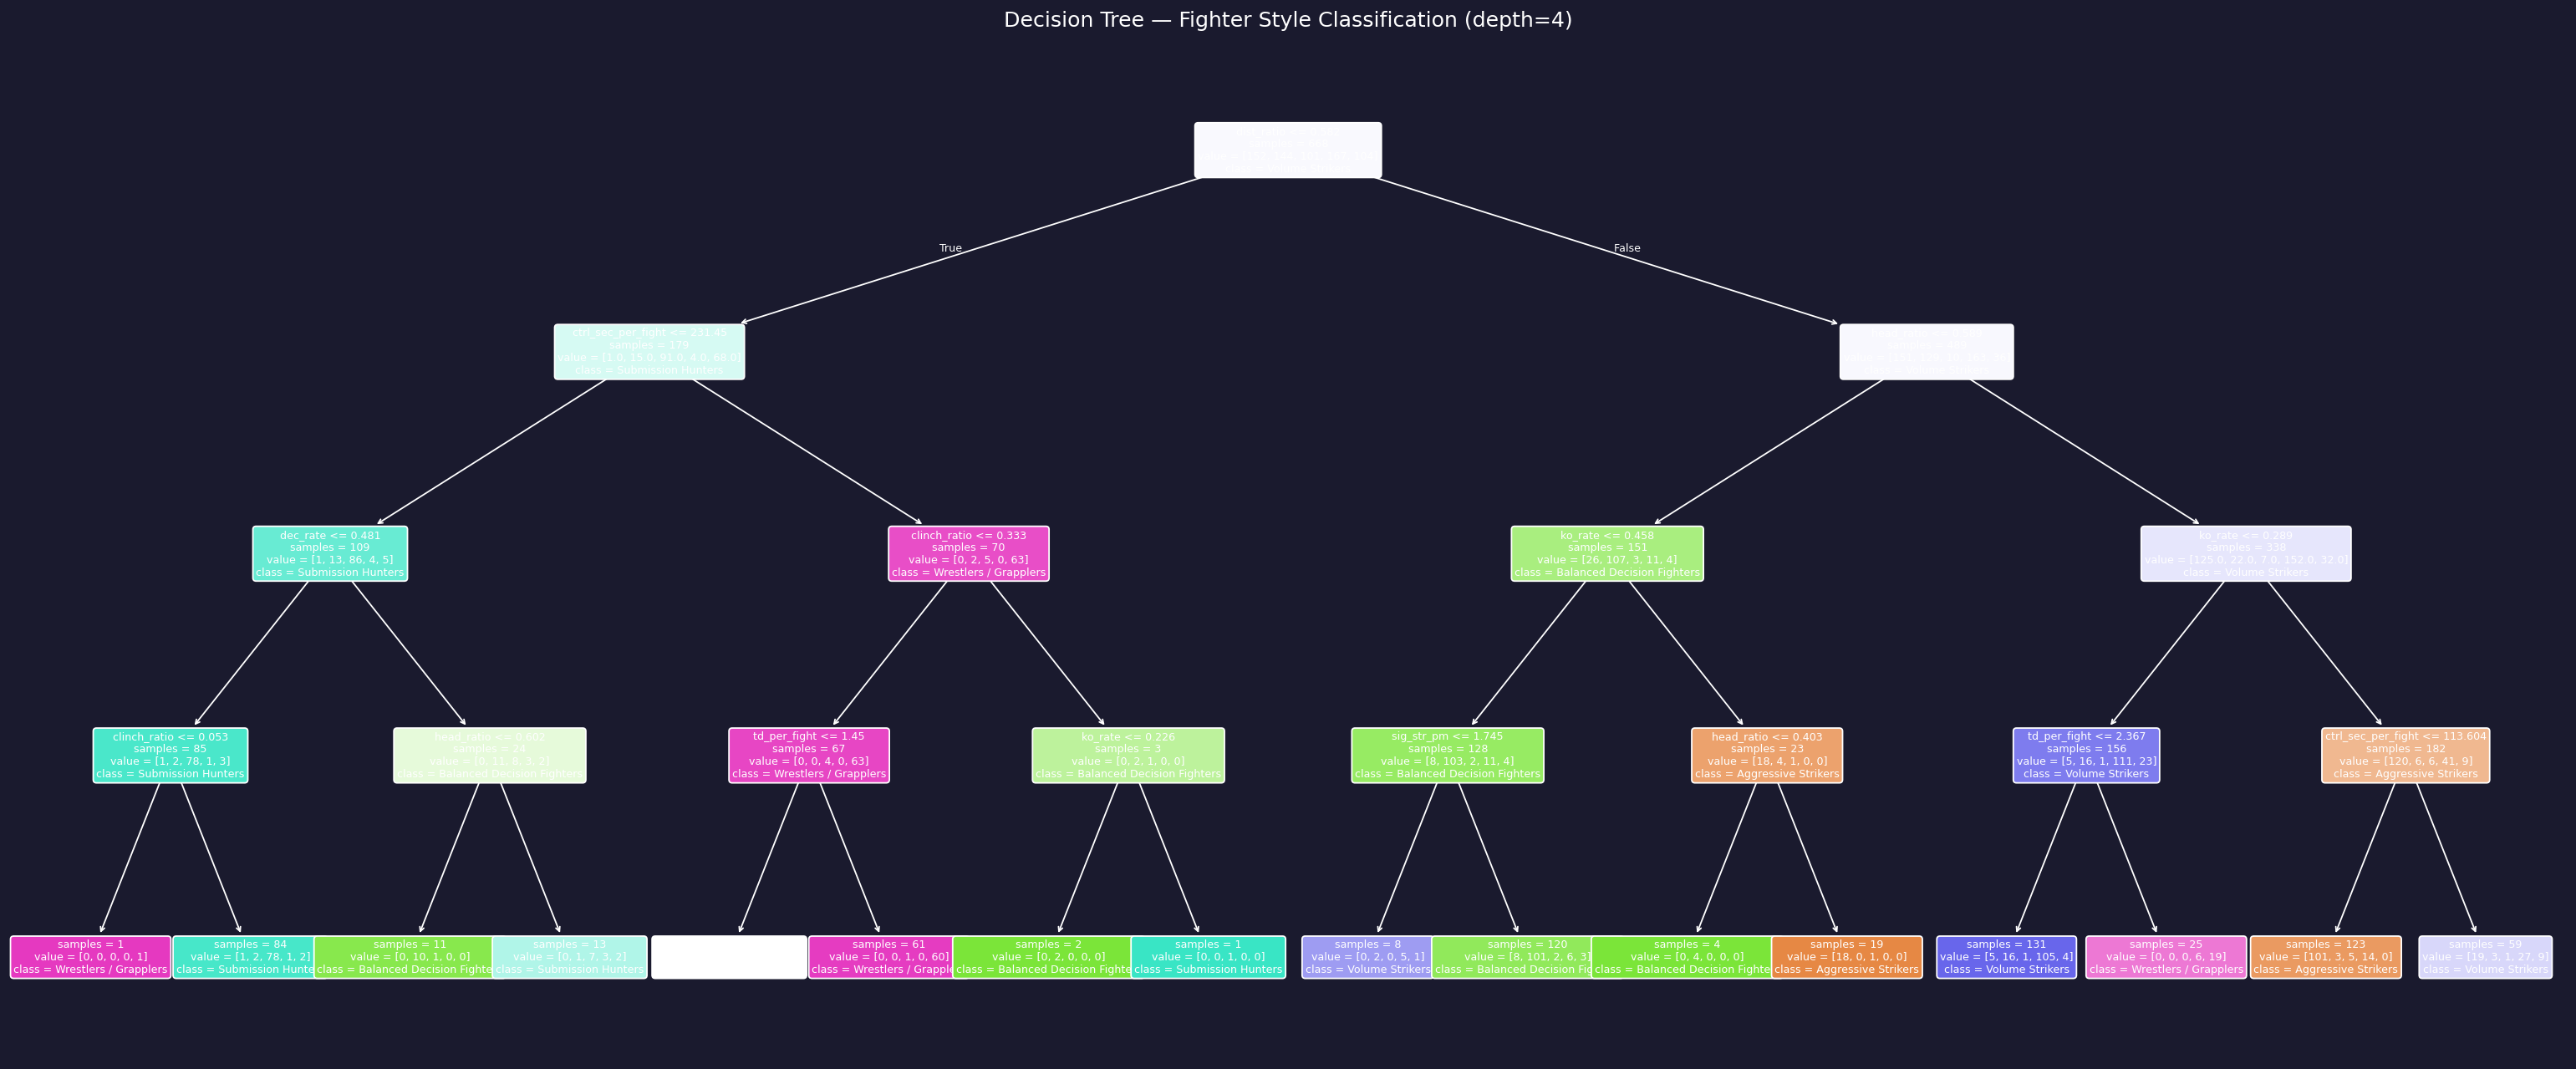

✅ Tree diagram saved


In [13]:
# ── Visual tree diagram ───────────────────────────────────────
# Use depth=4 for the visual (easier to read)
dt_visual = DecisionTreeClassifier(
    max_depth=4, criterion='gini', random_state=RANDOM_STATE
)
dt_visual.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 10))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

plot_tree(
    dt_visual,
    feature_names  = STYLE_FEATURES,
    class_names    = dt_visual.classes_,
    filled         = True,
    rounded        = True,
    fontsize       = 7,
    ax             = ax,
    impurity       = False,
    proportion     = False
)
ax.set_title('Decision Tree — Fighter Style Classification (depth=4)',
             fontsize=14, color='white', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'decision_tree_diagram.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Tree diagram saved')

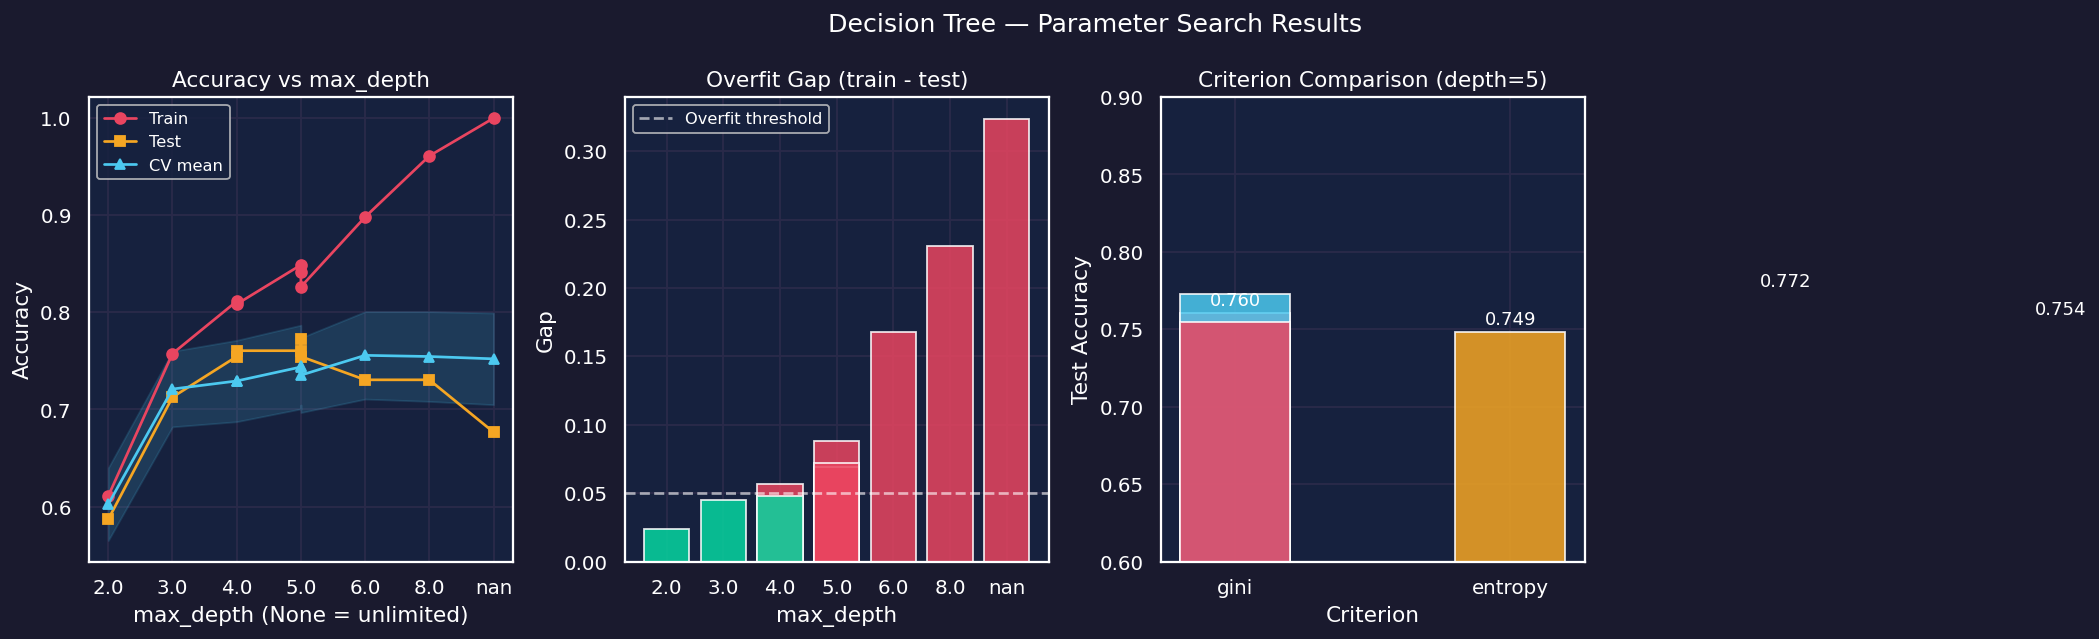

In [14]:
# ── Visualize DT parameter search results ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Decision Tree — Parameter Search Results', fontsize=14)

depth_df = dt_df[dt_df['criterion'] == 'gini'].sort_values('max_depth')
depth_labels = [str(d) for d in depth_df['max_depth']]

# Train vs test accuracy by depth
axes[0].plot(depth_labels, depth_df['train_acc'], color=ACCENT, marker='o', label='Train')
axes[0].plot(depth_labels, depth_df['test_acc'],  color=GOLD,   marker='s', label='Test')
axes[0].plot(depth_labels, depth_df['cv_mean'],   color=BLUE,   marker='^', label='CV mean')
axes[0].fill_between(depth_labels,
                     np.array(depth_df['cv_mean']) - np.array(depth_df['cv_std']),
                     np.array(depth_df['cv_mean']) + np.array(depth_df['cv_std']),
                     alpha=0.15, color=BLUE)
axes[0].set_title('Accuracy vs max_depth')
axes[0].set_xlabel('max_depth (None = unlimited)')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)

# Overfit gap by depth
axes[1].bar(depth_labels, depth_df['overfit'], color=[ACCENT if v > 0.05 else GREEN
                                                       for v in depth_df['overfit']], alpha=0.85)
axes[1].axhline(0.05, color='white', linestyle='--', alpha=0.6, label='Overfit threshold')
axes[1].set_title('Overfit Gap (train - test)')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Gap')
axes[1].legend(fontsize=9)

# Criterion comparison
crit_df = dt_df[dt_df['max_depth'] == 5]
crits   = crit_df['criterion'].values if len(crit_df) > 0 else ['gini']
vals    = crit_df['test_acc'].values   if len(crit_df) > 0 else [0]
axes[2].bar(crits, vals, color=[ACCENT, GOLD, BLUE][:len(crits)], alpha=0.85, width=0.4)
axes[2].set_title('Criterion Comparison (depth=5)')
axes[2].set_xlabel('Criterion')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_ylim(0.6, 0.9)
for i, v in enumerate(vals):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 4. Random Forest — Parameter Search

Random Forest trains hundreds of decision trees and combines them. It is more accurate but less interpretable. Every run is also logged to MLflow.

In [15]:
RF_PARAM_GRID = [
    {'n_estimators': 50,  'max_depth': 5,    'min_samples_split': 2,  'max_features': 'sqrt'},
    {'n_estimators': 50,  'max_depth': 8,    'min_samples_split': 2,  'max_features': 'sqrt'},
    {'n_estimators': 50,  'max_depth': None, 'min_samples_split': 2,  'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_split': 2,  'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_split': 2,  'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2,  'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_split': 2,  'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2,  'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_split': 5,  'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_split': 2,  'max_features': 'log2'},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_split': 5,  'max_features': 'sqrt'},
]

rf_results = []

print('Running Random Forest experiments (each logged to MLflow)...')
print(f'{"Params":60s} | train  | test   | cv_mean')
print('-' * 95)

for params in RF_PARAM_GRID:
    run_name = (f"RF_n{params['n_estimators']}_"
                f"depth{params['max_depth']}_"
                f"mss{params['min_samples_split']}_"
                f"feat{params['max_features']}")

    with mlflow.start_run(run_name=run_name):

        model = RandomForestClassifier(
            n_estimators      = params['n_estimators'],
            max_depth         = params['max_depth'],
            min_samples_split = params['min_samples_split'],
            max_features      = params['max_features'],
            random_state      = RANDOM_STATE,
            n_jobs            = -1
        )
        model.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc  = accuracy_score(y_test,  model.predict(X_test))
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        cv_mean   = cv_scores.mean()
        cv_std    = cv_scores.std()
        overfit   = train_acc - test_acc

        # ── Log to MLflow ─────────────────────────────────────
        mlflow.log_param('model_type',         'RandomForest')
        mlflow.log_param('n_estimators',       params['n_estimators'])
        mlflow.log_param('max_depth',          str(params['max_depth']))
        mlflow.log_param('min_samples_split',  params['min_samples_split'])
        mlflow.log_param('max_features',       params['max_features'])
        mlflow.log_param('test_size',          TEST_SIZE)

        mlflow.log_metric('train_accuracy',    round(train_acc, 4))
        mlflow.log_metric('test_accuracy',     round(test_acc,  4))
        mlflow.log_metric('cv_accuracy_mean',  round(cv_mean,   4))
        mlflow.log_metric('cv_accuracy_std',   round(cv_std,    4))
        mlflow.log_metric('overfit_gap',       round(overfit,   4))

        report = classification_report(y_test, model.predict(X_test),
                                       output_dict=True, zero_division=0)
        for cls in CLASSES:
            safe_cls = cls.replace(' ', '_').replace('/', '_')
            mlflow.log_metric(f'{safe_cls}_f1', round(report[cls]['f1-score'], 4))

        mlflow.sklearn.log_model(model, 'model')

        rf_results.append({
            **params,
            'train_acc': round(train_acc, 4),
            'test_acc':  round(test_acc,  4),
            'cv_mean':   round(cv_mean,   4),
            'cv_std':    round(cv_std,    4),
            'overfit':   round(overfit,   4),
            'run_name':  run_name
        })

    param_str = f"n={params['n_estimators']:3d} depth={str(params['max_depth']):4s} mss={params['min_samples_split']} feat={params['max_features']}"
    print(f'{param_str:60s} | {train_acc:.4f} | {test_acc:.4f} | {cv_mean:.4f}')

rf_df = pd.DataFrame(rf_results)
best_rf_row = rf_df.loc[rf_df['cv_mean'].idxmax()]
print(f'\n📌 Best RF by cv_mean: n={best_rf_row["n_estimators"]} depth={best_rf_row["max_depth"]} | cv={best_rf_row["cv_mean"]:.4f} | test={best_rf_row["test_acc"]:.4f}')

Running Random Forest experiments (each logged to MLflow)...
Params                                                       | train  | test   | cv_mean
-----------------------------------------------------------------------------------------------


2026/02/15 19:14:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


n= 50 depth=5    mss=2 feat=sqrt                             | 0.9192 | 0.8443 | 0.8419


2026/02/15 19:14:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


n= 50 depth=8    mss=2 feat=sqrt                             | 0.9955 | 0.8743 | 0.8790


...

n=100 depth=8    mss=5 feat=sqrt                             | 0.9955 | 0.8802 | 0.8707


2026/02/15 19:16:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


n=100 depth=8    mss=2 feat=log2                             | 0.9970 | 0.8802 | 0.8707


2026/02/15 19:16:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


n=200 depth=8    mss=5 feat=sqrt                             | 0.9970 | 0.8802 | 0.8754

📌 Best RF by cv_mean: n=50 depth=8.0 | cv=0.8790 | test=0.8743


---
## 5. Model Comparison

=== Model Comparison ===
               Model  Test Acc  CV Mean  CV Std  Overfit Interpretable
Decision Tree (best)    0.7305   0.7557  0.0450   0.1677         Yes ✅
Random Forest (best)    0.8743   0.8790  0.0139   0.1213         No  ❌


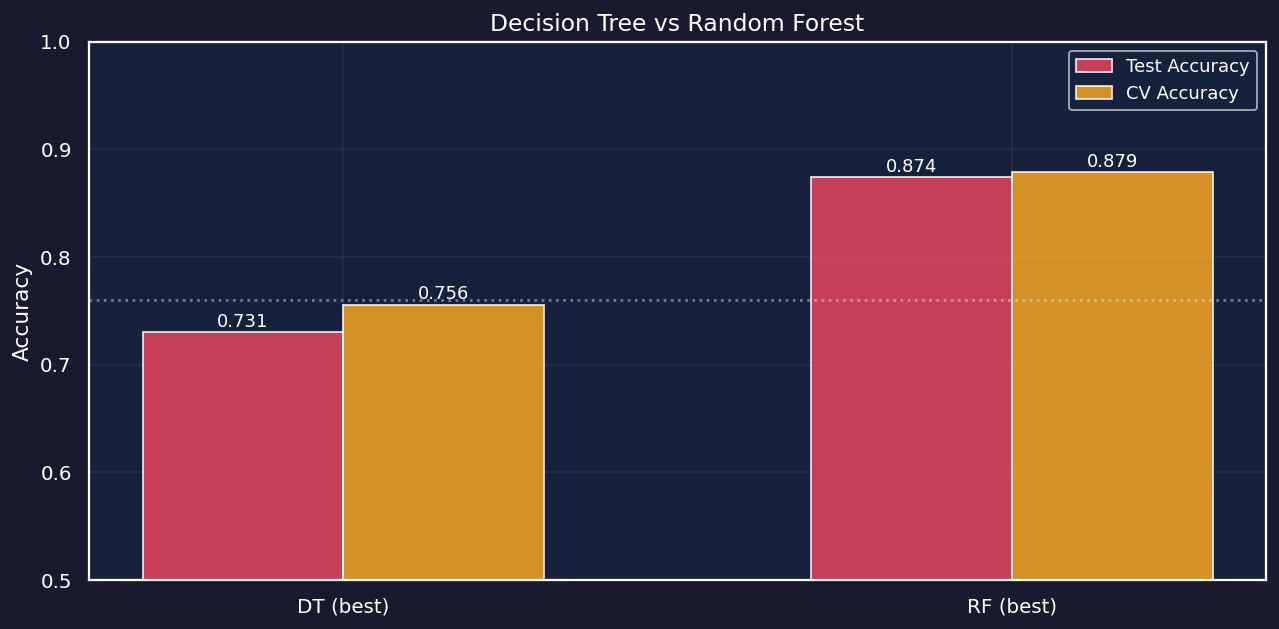

In [16]:
# ── Summary table ─────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': 'Decision Tree (best)',  'Test Acc': best_dt_row['test_acc'],
     'CV Mean': best_dt_row['cv_mean'], 'CV Std': best_dt_row['cv_std'],
     'Overfit': best_dt_row['overfit'], 'Interpretable': 'Yes ✅'},
    {'Model': 'Random Forest (best)',  'Test Acc': best_rf_row['test_acc'],
     'CV Mean': best_rf_row['cv_mean'], 'CV Std': best_rf_row['cv_std'],
     'Overfit': best_rf_row['overfit'], 'Interpretable': 'No  ❌'},
])
print('=== Model Comparison ===')
print(summary.to_string(index=False))

# Visual
fig, ax = plt.subplots(figsize=(10, 5))
models  = ['DT (best)', 'RF (best)']
test_accs = [best_dt_row['test_acc'], best_rf_row['test_acc']]
cv_means  = [best_dt_row['cv_mean'],  best_rf_row['cv_mean']]

x = np.arange(len(models))
w = 0.3
ax.bar(x - w/2, test_accs, w, label='Test Accuracy', color=ACCENT, alpha=0.85)
ax.bar(x + w/2, cv_means,  w, label='CV Accuracy',   color=GOLD,   alpha=0.85)

for i, (ta, cv) in enumerate(zip(test_accs, cv_means)):
    ax.text(i - w/2, ta + 0.005, f'{ta:.3f}', ha='center', fontsize=10)
    ax.text(i + w/2, cv + 0.005, f'{cv:.3f}', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1.0)
ax.set_title('Decision Tree vs Random Forest', fontsize=13)
ax.set_ylabel('Accuracy')
ax.legend(fontsize=10)
ax.axhline(0.76, color='white', linestyle=':', alpha=0.4, label='DT test baseline')
plt.tight_layout()
plt.show()

---
## 6. Feature Importance

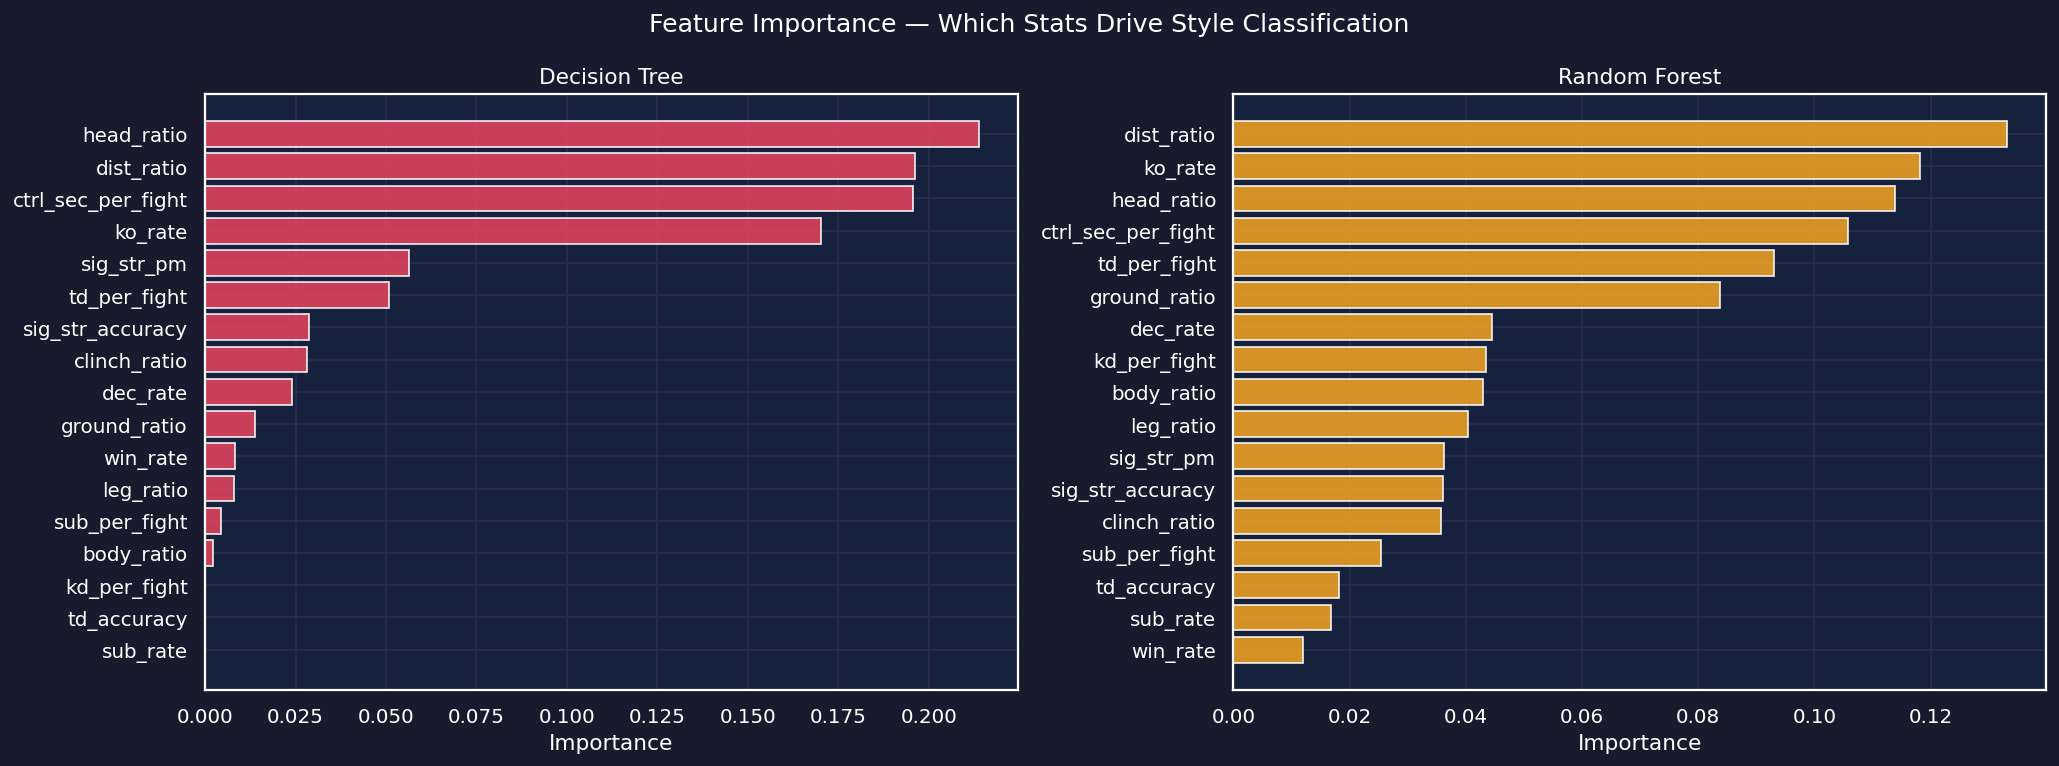


Top 5 most important features:
  Decision Tree: ['head_ratio', 'dist_ratio', 'ctrl_sec_per_fight', 'ko_rate', 'sig_str_pm']
  Random Forest: ['dist_ratio', 'ko_rate', 'head_ratio', 'ctrl_sec_per_fight', 'td_per_fight']


In [17]:
# ── Retrain best RF ───────────────────────────────────────────
best_rf = RandomForestClassifier(
    n_estimators      = int(best_rf_row['n_estimators']),
    max_depth         = None if str(best_rf_row['max_depth']) == 'None' else int(best_rf_row['max_depth']),
    min_samples_split = int(best_rf_row['min_samples_split']),
    max_features      = best_rf_row['max_features'],
    random_state      = RANDOM_STATE,
    n_jobs            = -1
)
best_rf.fit(X_train, y_train)

fi_dt = pd.Series(best_dt.feature_importances_, index=STYLE_FEATURES).sort_values(ascending=False)
fi_rf = pd.Series(best_rf.feature_importances_, index=STYLE_FEATURES).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — Which Stats Drive Style Classification', fontsize=14)

ax1.barh(fi_dt.index, fi_dt.values, color=ACCENT, alpha=0.85)
ax1.set_title('Decision Tree')
ax1.set_xlabel('Importance')
ax1.invert_yaxis()

ax2.barh(fi_rf.index, fi_rf.values, color=GOLD, alpha=0.85)
ax2.set_title('Random Forest')
ax2.set_xlabel('Importance')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print('  Decision Tree:', fi_dt.head(5).index.tolist())
print('  Random Forest:', fi_rf.head(5).index.tolist())

---
## 7. Confusion Matrix & Error Analysis

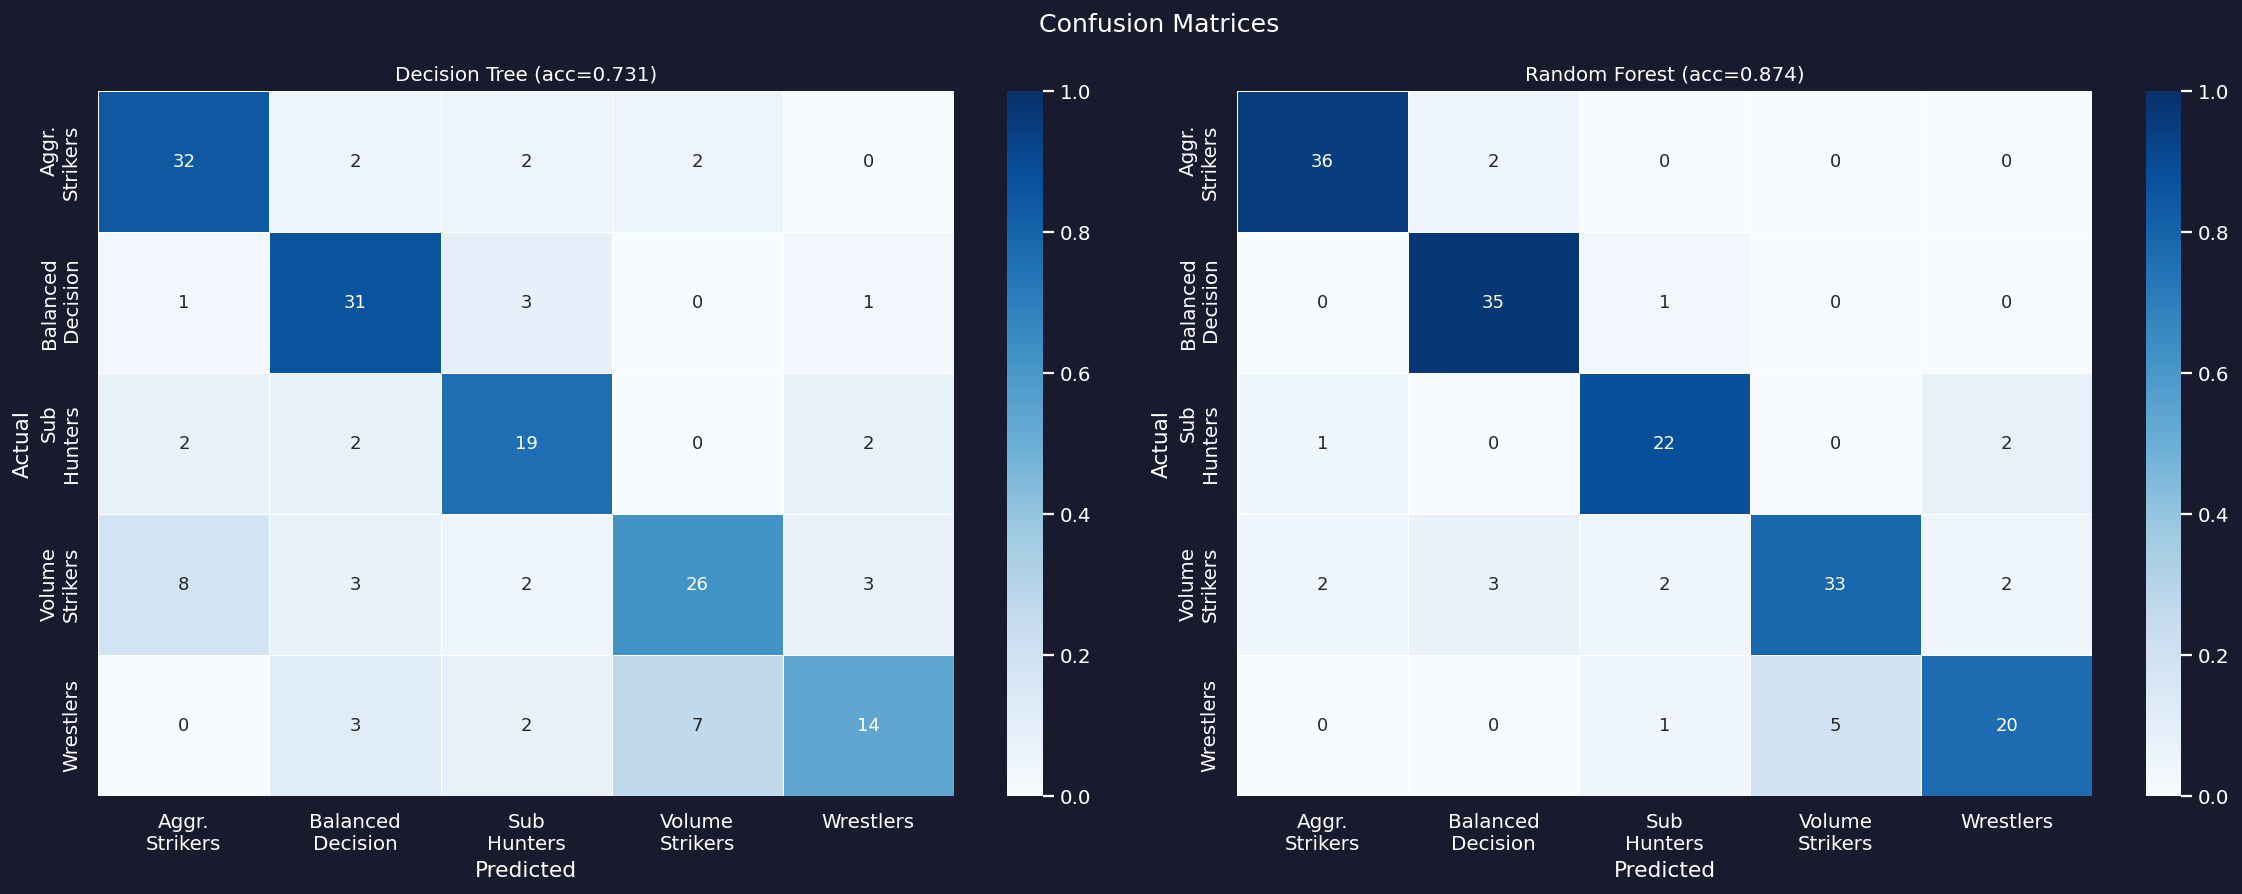

In [18]:
y_pred_rf = best_rf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrices', fontsize=14)

short_labels = ['Aggr.\nStrikers', 'Balanced\nDecision', 'Sub\nHunters',
                'Volume\nStrikers', 'Wrestlers']

for ax, y_pred, title in [
    (axes[0], y_pred_dt, f'Decision Tree (acc={accuracy_score(y_test, y_pred_dt):.3f})'),
    (axes[1], y_pred_rf, f'Random Forest (acc={accuracy_score(y_test, y_pred_rf):.3f})')
]:
    cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=cm, fmt='d',
        cmap='Blues', ax=ax,
        xticklabels=short_labels,
        yticklabels=short_labels,
        vmin=0, vmax=1,
        linewidths=0.5,
        annot_kws={'size': 10}
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# ── Full classification report ────────────────────────────────
print('=== Decision Tree — Classification Report ===')
print(classification_report(y_test, y_pred_dt, zero_division=0))

print('=== Random Forest — Classification Report ===')
print(classification_report(y_test, y_pred_rf, zero_division=0))

=== Decision Tree — Classification Report ===
                            precision    recall  f1-score   support

       Aggressive Strikers       0.74      0.84      0.79        38
Balanced Decision Fighters       0.76      0.86      0.81        36
        Submission Hunters       0.68      0.76      0.72        25
           Volume Strikers       0.74      0.62      0.68        42
     Wrestlers / Grapplers       0.70      0.54      0.61        26

                  accuracy                           0.73       167
                 macro avg       0.72      0.72      0.72       167
              weighted avg       0.73      0.73      0.73       167

=== Random Forest — Classification Report ===
                            precision    recall  f1-score   support

       Aggressive Strikers       0.92      0.95      0.94        38
Balanced Decision Fighters       0.88      0.97      0.92        36
        Submission Hunters       0.85      0.88      0.86        25
           Volume St

In [20]:
# ── Misclassified fighters analysis ───────────────────────────
# Identify fighters the model got wrong and why
test_indices = np.where(
    np.isin(df['style_label'].values, y_test)
)[0][:len(y_test)]

# Rebuild test set with fighter names
df_test = df.iloc[
    train_test_split(
        np.arange(len(df)), test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )[1]
].copy()

df_test['predicted_dt'] = y_pred_dt
df_test['predicted_rf'] = y_pred_rf
df_test['correct_dt']   = df_test['style_label'] == df_test['predicted_dt']
df_test['correct_rf']   = df_test['style_label'] == df_test['predicted_rf']

misclassified_dt = df_test[~df_test['correct_dt']]
print(f'Fighters misclassified by DT: {len(misclassified_dt)} / {len(df_test)}')
print(f'Fighters misclassified by RF: {(~df_test["correct_rf"]).sum()} / {len(df_test)}')

print('\n=== Sample Misclassified Fighters (DT) ===')
print('These are borderline fighters — genuinely mixed-style athletes')
cols = ['Fighter_Name','style_label','predicted_dt','sig_str_pm','td_per_fight','sub_per_fight']
print(misclassified_dt[cols].head(12).to_string(index=False))

Fighters misclassified by DT: 45 / 167
Fighters misclassified by RF: 21 / 167

=== Sample Misclassified Fighters (DT) ===
These are borderline fighters — genuinely mixed-style athletes
      Fighter_Name                style_label               predicted_dt  sig_str_pm  td_per_fight  sub_per_fight
        Ryan Spann            Volume Strikers        Aggressive Strikers    2.999215      0.600000       0.700000
  Daniel Rodriguez        Aggressive Strikers Balanced Decision Fighters    8.511843      0.333333       0.000000
    Eddie Wineland        Aggressive Strikers            Volume Strikers    3.236971      0.250000       0.000000
       Tim Boetsch         Submission Hunters        Aggressive Strikers    2.883317      0.384615       0.538462
        Alex White            Volume Strikers        Aggressive Strikers    2.780779      0.600000       0.600000
     Felice Herrig            Volume Strikers Balanced Decision Fighters    4.010466      1.000000       0.833333
     Randy Coutur

---
## 8. Predict a New Fighter



In [21]:
def predict_fighter_style(stats_dict, model=best_rf, verbose=True):
    """
    Predict the fighting style of a fighter given their stats.

    Parameters
    ----------
    stats_dict : dict
        Fighter stats. Any missing feature defaults to the dataset median.
    model : trained classifier
    verbose : bool

    Returns
    -------
    str : predicted style label
    """
    medians   = df[STYLE_FEATURES].median()
    input_vec = medians.copy()
    for feat, val in stats_dict.items():
        if feat in STYLE_FEATURES:
            input_vec[feat] = val

    X_new      = input_vec.values.reshape(1, -1)
    prediction = model.predict(X_new)[0]
    proba      = model.predict_proba(X_new)[0]
    proba_dict = dict(zip(model.classes_, proba))

    if verbose:
        print(f'\n🥊 Predicted Style: {prediction}')
        print('\nConfidence per style:')
        for style, prob in sorted(proba_dict.items(), key=lambda x: -x[1]):
            bar = '█' * int(prob * 30)
            print(f'  {style:35s} {bar} {prob*100:.1f}%')

    return prediction


# ── Example: Khabib-like profile ──────────────────────────────
print('--- Example 1: Khabib-like fighter (dominant wrestler) ---')
predict_fighter_style({
    'td_per_fight'       : 5.2,
    'ctrl_sec_per_fight' : 280,
    'ground_ratio'       : 0.45,
    'dist_ratio'         : 0.35,
    'ko_rate'            : 0.05,
    'dec_rate'           : 0.80,
    'sub_rate'           : 0.15,
})

print('\n--- Example 2: Adesanya-like fighter (pure striker) ---')
predict_fighter_style({
    'sig_str_pm'         : 5.1,
    'dist_ratio'         : 0.88,
    'head_ratio'         : 0.65,
    'leg_ratio'          : 0.18,
    'td_per_fight'       : 0.1,
    'ko_rate'            : 0.45,
    'dec_rate'           : 0.45,
})

print('\n--- Example 3: Charles Oliveira-like fighter (submission hunter) ---')
predict_fighter_style({
    'sub_per_fight'      : 1.8,
    'sub_rate'           : 0.55,
    'ground_ratio'       : 0.35,
    'td_per_fight'       : 1.2,
    'ko_rate'            : 0.25,
    'dec_rate'           : 0.20,
})

--- Example 1: Khabib-like fighter (dominant wrestler) ---

🥊 Predicted Style: Wrestlers / Grapplers

Confidence per style:
  Wrestlers / Grapplers               ████████████████████████████ 95.2%
  Submission Hunters                  █ 4.2%
  Balanced Decision Fighters           0.5%
  Volume Strikers                      0.1%
  Aggressive Strikers                  0.0%

--- Example 2: Adesanya-like fighter (pure striker) ---

🥊 Predicted Style: Aggressive Strikers

Confidence per style:
  Aggressive Strikers                 ████████████████████████ 80.9%
  Volume Strikers                     ███ 11.7%
  Balanced Decision Fighters          █ 6.2%
  Wrestlers / Grapplers                0.9%
  Submission Hunters                   0.3%

--- Example 3: Charles Oliveira-like fighter (submission hunter) ---

🥊 Predicted Style: Volume Strikers

Confidence per style:
  Volume Strikers                     █████████████████ 59.6%
  Submission Hunters                  ███████ 24.6%
  Wrestlers /

'Volume Strikers'

---
## 9. Save Best Model & Final MLflow Run

In [26]:
# ── Decide which model to save as final ───────────────────────
# RF is more accurate; DT is more interpretable
# We save BOTH and tag the RF as the production model

DT_PATH = PROJECT_PATH +'/'+ 'best_decision_tree.pkl'
RF_PATH = PROJECT_PATH + '/'+'best_random_forest.pkl'

with open(DT_PATH, 'wb') as f:
    pickle.dump(best_dt, f)
with open(RF_PATH, 'wb') as f:
    pickle.dump(best_rf, f)

print(f'✅ Decision Tree saved : {DT_PATH}')
print(f'✅ Random Forest saved : {RF_PATH}')

✅ Decision Tree saved : /content/drive/MyDrive/Colab Notebooks/UFC Project/best_decision_tree.pkl
✅ Random Forest saved : /content/drive/MyDrive/Colab Notebooks/UFC Project/best_random_forest.pkl


In [27]:
# ── Final summary MLflow run ───────────────────────────────────
with mlflow.start_run(run_name='FINAL_best_models_summary'):

    # Best DT
    mlflow.log_param('best_dt_depth',           str(BEST_DT_DEPTH))
    mlflow.log_param('best_dt_criterion',       BEST_DT_CRIT)
    mlflow.log_param('best_dt_min_samples_split', BEST_DT_MSS)
    mlflow.log_metric('best_dt_test_accuracy',  best_dt_row['test_acc'])
    mlflow.log_metric('best_dt_cv_mean',        best_dt_row['cv_mean'])

    # Best RF
    mlflow.log_param('best_rf_n_estimators',    int(best_rf_row['n_estimators']))
    mlflow.log_param('best_rf_max_depth',       str(best_rf_row['max_depth']))
    mlflow.log_metric('best_rf_test_accuracy',  best_rf_row['test_acc'])
    mlflow.log_metric('best_rf_cv_mean',        best_rf_row['cv_mean'])

    # Dataset info
    mlflow.log_param('n_fighters',              len(df))
    mlflow.log_param('n_features',              len(STYLE_FEATURES))
    mlflow.log_param('n_classes',               len(CLASSES))
    mlflow.log_param('test_size',               TEST_SIZE)

    # Top feature importances (RF)
    for feat, imp in fi_rf.head(5).items():
        mlflow.log_metric(f'rf_importance_{feat}', round(imp, 4))

    # Artifacts
    mlflow.log_artifact(DT_PATH)
    mlflow.log_artifact(RF_PATH)
    mlflow.log_artifact(OUTPUT_DIR + 'decision_tree_diagram.png')

    run_id = mlflow.active_run().info.run_id

print(f'✅ Final MLflow run logged  |  run_id: {run_id}')

✅ Final MLflow run logged  |  run_id: 59809548cc434056bd29307b8dc813d7
